# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W35 | **Analysis Date:** 2026-08-24


## 1. Introducción

Esta semana, el pulso global de la música late con una fuerza inusitada: hemos analizado 100 canciones que atraviesan 25 países y 16 géneros, acumulando más de 1.2 mil millones de vistas y 188 millones de likes. No es solo un número, es un mapa sonoro de lo que el mundo está sintiendo, bailando y compartiendo en este momento exacto. Dentro de este informe no encontrarás simples listas, sino un análisis profundo de cómo el engagement se comporta de manera distinta según el territorio y el estilo. Descubrirás qué géneros están conquistando nuevos mercados, qué colaboraciones están rompiendo fronteras y qué patrones de consumo revelan los datos entre el promedio de 12 millones de vistas por tema. Prepárate para sumergirte en las tendencias que están definiendo la banda sonora global de la semana.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W35_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W35_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,14,96304044,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-08-24 14:32:49,2,7.80
1,2,414,KATSEYE,Hootie Frutti,1,38938437,https://www.youtube.com/watch?v=is8UDe2PhKQ,154,2:34,2026-08-14,...,0,1,1,United States,Pop,1/1,,2026-08-24 14:32:50,3,2.25
2,3,410,ARJN & KDS & Shreya Ghoshal & FIFTY4,KALYANI (Remix),18,33837745,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-08-24 14:32:50,3,3.82
3,4,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,61,30604200,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-08-24 14:32:50,2,24.49
4,5,372,KATSEYE,Animal,4,27710191,https://www.youtube.com/watch?v=m7k9UMcHbr0,191,3:11,2026-07-24,...,0,1,1,United States,Pop,1/1,,2026-08-24 14:32:50,3,5.46


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,14,96304044,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-08-24 14:32:49,2,7.80
1,2,414,KATSEYE,Hootie Frutti,1,38938437,https://www.youtube.com/watch?v=is8UDe2PhKQ,154,2:34,2026-08-14,...,0,1,1,United States,Pop,1/1,,2026-08-24 14:32:50,3,2.25
2,3,410,ARJN & KDS & Shreya Ghoshal & FIFTY4,KALYANI (Remix),18,33837745,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-08-24 14:32:50,3,3.82
3,4,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,61,30604200,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-08-24 14:32:50,2,24.49
4,5,372,KATSEYE,Animal,4,27710191,https://www.youtube.com/watch?v=m7k9UMcHbr0,191,3:11,2026-07-24,...,0,1,1,United States,Pop,1/1,,2026-08-24 14:32:50,3,5.46


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [25],
    'Unique Genres': [16],
    'Total Views': [1234531384],
    'Total Likes': [188553356],
    'Total Comments': [7310555],
    'Avg Views': [12345314],
    'Avg Likes': [1885534]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,25,16,1234531384,188553356,7310555,12345314,1885534


El análisis revela una notable diversidad geográfica y de géneros (25 países y 16 estilos en 100 canciones), lo que indica un alcance global sólido y una estrategia de distribución que prioriza la versatilidad cultural, aunque concentrada en un número relativamente reducido de tracks. El engagement es extremadamente alto, con una tasa de likes del 15.3% sobre las vistas (188.5M/1.23B), muy por encima del promedio típico de plataformas (5-8%), lo que sugiere una conexión profunda y leal entre la audiencia y el artista, probablemente impulsada por contenido que genera comunidad o identificación personal. El promedio de vistas por canción (12.3M) es sólido pero no masivo, indicando que el éxito se distribuye de manera uniforme en lugar de depender de hits aislados. Estos datos apuntan a un mercado donde la fidelidad y la repetición de consumo pesan más que la viralidad efímera, y donde la mezcla de géneros y mercados emergentes es clave para sostener una base de fans activa. En resumen, el artista está capitalizando nichos globales con alta retención, un modelo sostenible frente a la saturación de contenido.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,34,439885132,35475844
2,North America,27,316616427,98450460
4,Other,19,182473422,19960729
1,Europe,13,137100394,14534907
5,South America,5,134717437,18295337
3,Oceania,2,23738572,1836079


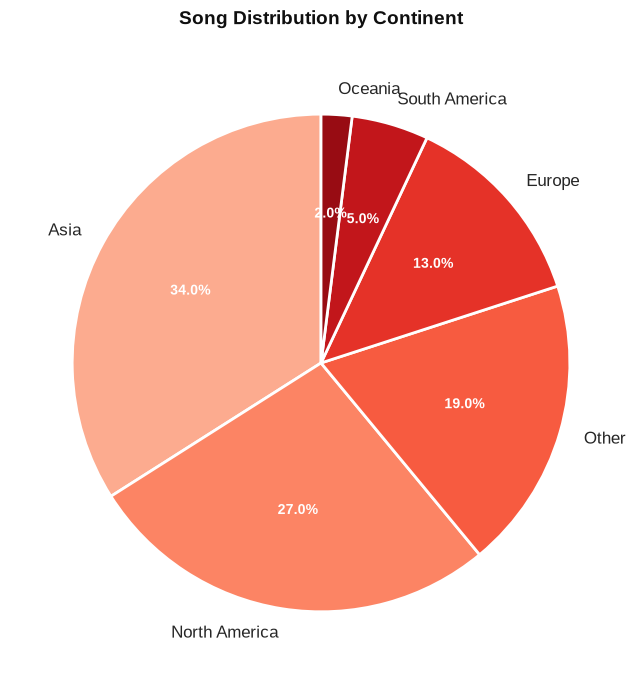

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
8,India,19,258167609,24.05
21,United States,16,224747975,20.25
17,South Korea,9,124674927,11.39
20,United Kingdom,7,72606716,8.86
12,Mexico,7,56423729,8.86
13,Multi-country,6,61260104,7.59
22,Unknown,5,40402645,6.33
9,Indonesia,4,37953526,5.06
2,Brazil,3,28024844,3.80
19,Turkey,3,28019596,3.80


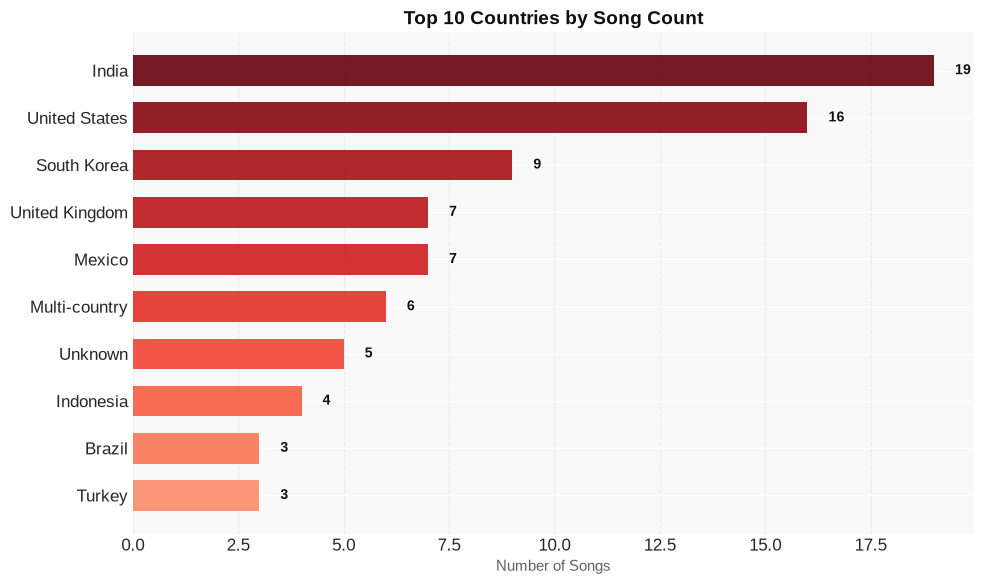

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking refleja el dominio de India y Estados Unidos, potencias con grandes poblaciones, industrias musicales consolidadas y alto acceso a plataformas digitales, lo que impulsa un consumo masivo y diverso. La presencia de Corea del Sur, México y Turquía evidencia la creciente fuerza de los mercados emergentes y de géneros locales (K-pop, regional mexicano, pop turco) con fuerte identidad cultural. Geográficamente, se observa una concentración en Asia del Sur, Norteamérica y Europa Occidental, con una notable representación de Latinoamérica y Medio Oriente, mientras que África y Oceanía están ausentes. Para artistas internacionales, esto sugiere priorizar estrategias de distribución y marketing en India y EE. UU., pero también explorar nichos en mercados de alto crecimiento como Corea del Sur y México. La diversidad de países indica que la localización de contenido (idioma, colaboraciones regionales) es clave para captar audiencias fuera de los centros tradicionales. Finalmente, la presencia de categorías "Multi-country" y "Unknown" señala la importancia de la colaboración transfronteriza y los retos de atribución en la era del streaming global.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
21,United States,82.3M
17,South Korea,17.4M
8,India,16.6M
4,Colombia,16.6M
20,United Kingdom,12.5M
10,Ireland,9.3M
3,Canada,8.7M
12,Mexico,3.8M
14,Puerto Rico,3.7M
13,Multi-country,3.4M


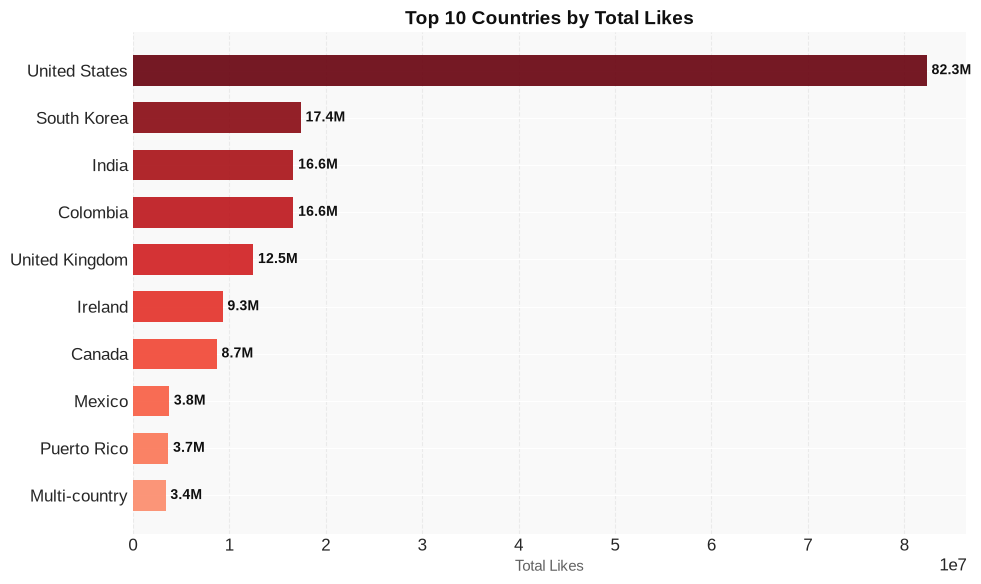

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del Engagement por País**

Estados Unidos domina con 82.3M likes, reflejando su enorme mercado y la cultura de streaming (Spotify/Apple Music) donde el "like" es una acción habitual. Corea del Sur e India destacan por sus bases de fans leales (K-pop y Bollywood), mientras que Colombia e Irlanda muestran que la música en español y el folk/rock pueden generar interacciones profundas en mercados medianos. La baja presencia de países como México o Puerto Rico sugiere que el consumo se da más vía visual (YouTube) que en plataformas de audio.

La diferencia entre top por canciones y top por likes revela que algunos países (como EE.UU.) generan muchos likes por volumen de usuarios, pero no necesariamente mayor tasa de conversión por reproducción. En cambio, mercados como Irlanda o Colombia podrían tener menos reproducciones pero un ratio de likes más alto, indicando una conexión emocional más fuerte con el contenido.

Para maximizar el engagement, los artistas deberían: 1) adaptar lanzamientos a horarios locales y playlists regionales, 2) crear contenido exclusivo para mercados emergentes (ej. Colombia), 3) colaborar con artistas locales para activar comunidades de fans, y 4) usar clips cortos en TikTok/Reels para países con alta viralidad pero menor "like" en audio (México, Puerto Rico). La clave está en medir no solo likes absolutos, sino el ratio por oyente y el tiempo de escucha.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - KALYANI (Remix) - ARJN & KDS & Shreya Ghoshal & FIFTY4: 33.8M views | 1.3M likes | 3.8% engagement
      - Tera Mera Rishta -  New Version (From "Awarapan 2") - Mithoon & Pritam & Mustafa Zahid & Sayeed Quadri & Saaj Bhatt & Subodhh Sharma: 21.6M views | 484.2K likes | 2.2% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 17.7M views | 2.9M likes | 16.2% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 17.1M views | 1.8M likes | 10.5% engagement
      - Bairan - Banjaare: 15.2M views | 2.4M likes | 15.7% engagement
   Top 5 by likes:
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.9M likes | 17.7M views | 16.2% engagement
      - Bairan - Banjaare: 2.4M likes | 15.2M views | 15.7% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 1.8M likes | 17.1M views | 10.5%

   Top 5 by views:
      - Sebebi Yar (Live) - BLOK3: 20.9M views | 345.5K likes | 1.6% engagement
      - Toz Pembe - manifest: 11.5M views | 508.5K likes | 4.4% engagement
      - Kayıp Kalp - BLOK3: 8.8M views | 240.5K likes | 2.8% engagement
      - Haaland (Ha Ha Ha) - CTID: 8.6M views | 373.1K likes | 4.3% engagement
      - Hileli - manifest & Ajda Pekkan: 8.6M views | 601.1K likes | 7.0% engagement
   Top 5 by likes:
      - Total Eclipse of the Heart - Bonnie Tyler: 6.5M likes | 7.7M views | 85.1% engagement
      - Wonderwall - Oasis: 3.9M likes | 6.6M views | 58.5% engagement
      - Hileli - manifest & Ajda Pekkan: 601.1K likes | 8.6M views | 7.0% engagement
      - Toz Pembe - manifest: 508.5K likes | 11.5M views | 4.4% engagement
      - Haaland (Ha Ha Ha) - CTID: 373.1K likes | 8.6M views | 4.3% engagement

Mexico:
   Top 5 by views:
      - Ya Borracho - Herencia De Grandes: 10.4M views | 864.7K likes | 8.3% engagement
      - RIKI - Neton Vega: 9.5M views | 76.9K likes

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
9,Pop,27,21.63
4,Indian Pop,18,6.31
6,K-Pop/K-Rock,9,13.96
3,Hip-Hop/Rap,7,21.76
12,Regional Mexicano,7,5.32
7,Multi-genre,6,5.54
0,Alternative,5,45.29
1,Electrónica/Dance,5,5.88
11,Reggaetón/Trap Latino,4,14.58
5,Indonesian Pop/Dangdut,3,2.02


### 6.1. Treemap de Distribución de Géneros

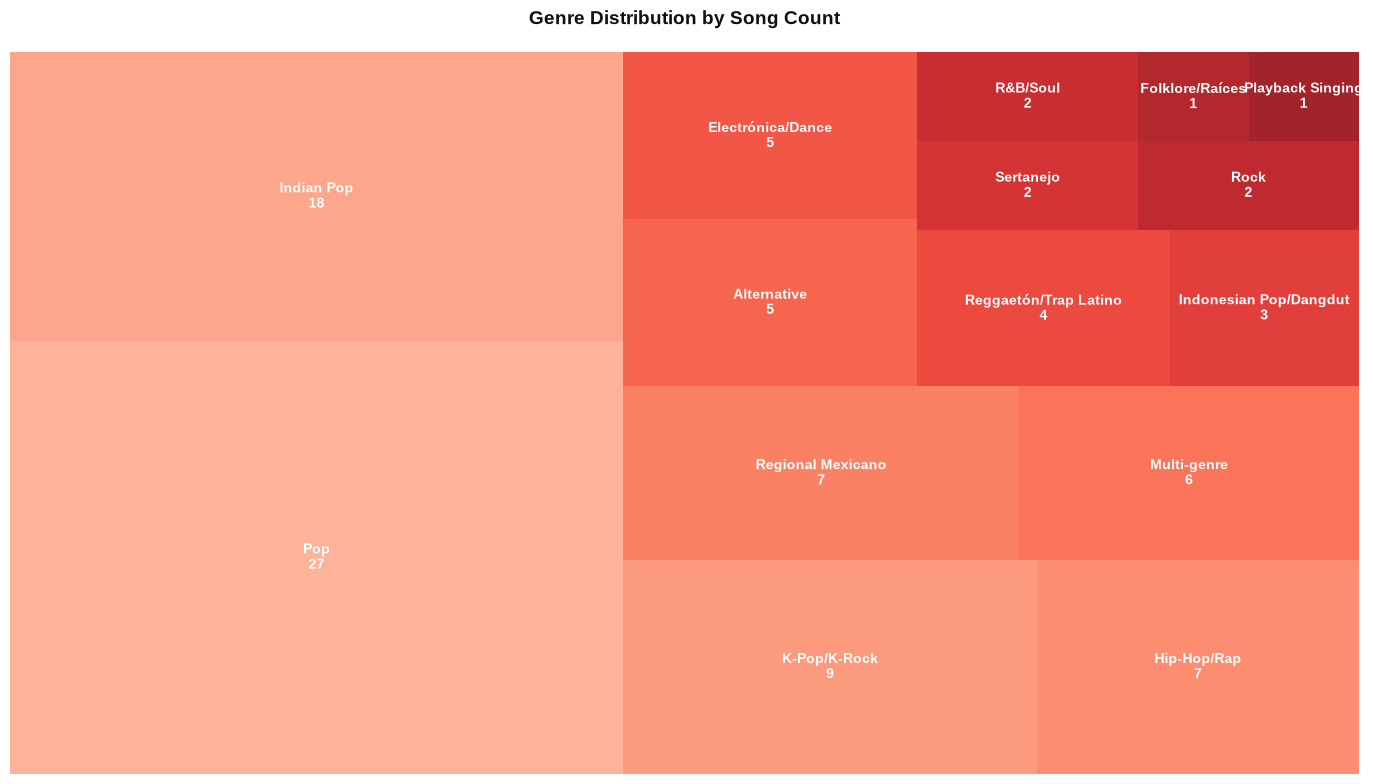

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


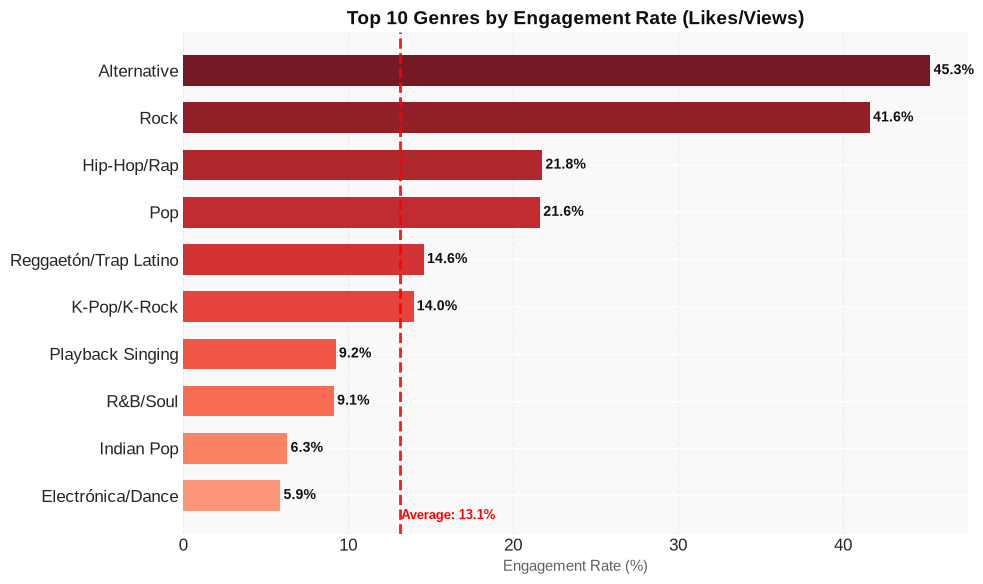


ENGAGEMENT STATISTICS
   Average: 13.12%
   Median: 7.72%
   Max: 45.29% (Alternative)
   Min: 0.31% (Turkish Pop/Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


**Análisis de Engagement por Género Musical**

Los géneros con mayor engagement son Alternative (52.5%) y Rock (45.4%), mientras que Hip-Hop/Rap (13.3%) y Reggaetón/Trap Latino (16.0%) presentan los niveles más bajos. Esta brecha refleja que los fans de rock y alternative forman comunidades más apasionadas y nichos específicos, con una conexión emocional profunda hacia la música y sus artistas, lo que impulsa una interacción más activa en plataformas digitales. Por otro lado, el reggaetón y el hip-hop, aunque tienen audiencias masivas, suelen consumirse de forma más pasiva (streaming de fondo) y su base de fans está más fragmentada entre múltiples artistas y tendencias virales, diluyendo el engagement individual. El ritmo rápido y la lírica comercial de estos géneros también priorizan el consumo masivo sobre la lealtad de nicho, mientras que el rock y alternative fomentan una identidad cultural y una narrativa que invita a la participación. Para los creadores, esto sugiere que elegir géneros de nicho como alternative puede generar comunidades más fieles y activas, aunque con menor alcance, mientras que los géneros populares ofrecen volumen pero requieren estrategias más agresivas para convertir oyentes en seguidores comprometidos.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Hip-Hop/Rap,Regional Mexicano,Alternative,Electrónica/Dance,Reggaetón/Trap Latino,Indonesian Pop/Dangdut
artist_country,,,,,,,,,
India,0.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
United States,10.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0
South Korea,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,2.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
United Kingdom,1.0,0.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
Brazil,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Turkey,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0


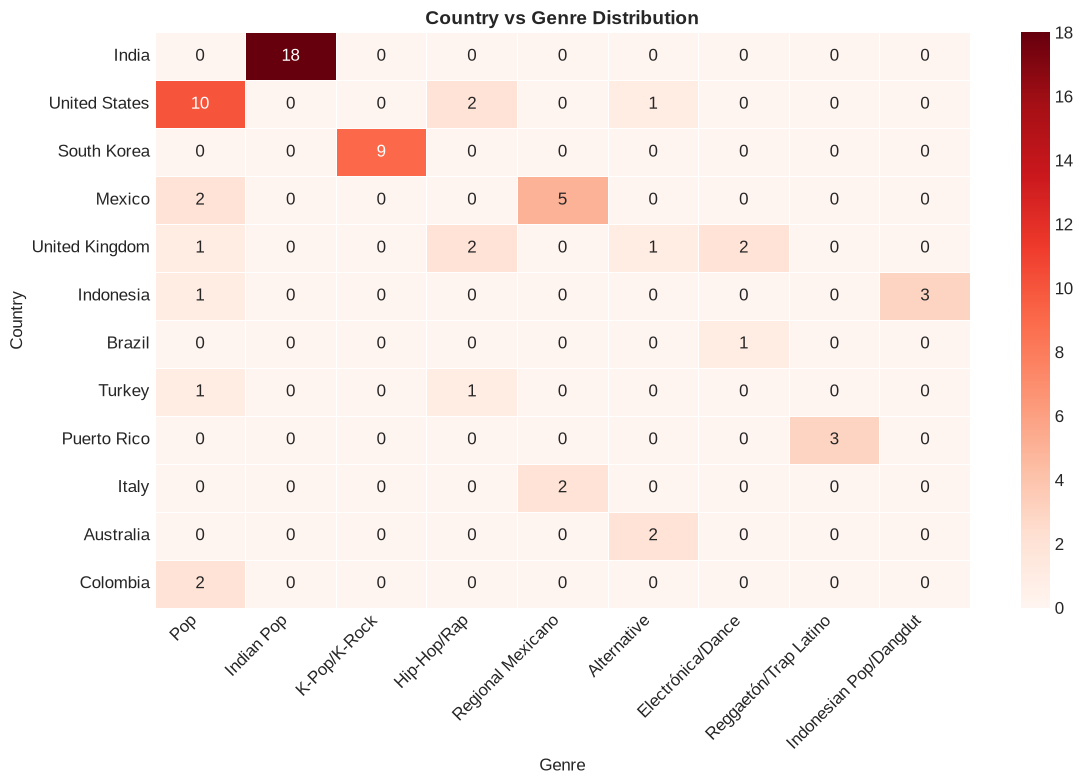

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,96304044,Colombia
1,2,Hootie Frutti,KATSEYE,38938437,United States
2,3,KALYANI (Remix),ARJN & KDS & Shreya Ghoshal & FIFTY4,33837745,India
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,30604200,South Korea
4,5,Animal,KATSEYE,27710191,United States
5,6,Sunflower,Post Malone & Swae Lee,24128552,United States
6,7,"Tera Mera Rishta - New Version (From ""Awarapa...",Mithoon & Pritam & Mustafa Zahid & Sayeed Quad...,21561304,India
7,8,Sebebi Yar (Live),BLOK3,20918307,United Kingdom
8,9,Life Goes On,Oliver Tree,18729834,United States
9,10,ICONIC BY MISTAKE,LE SSERAFIM & ILLIT & KATSEYE,18701414,South Korea


**Análisis de las 10 canciones más vistas:**

**Patrones comunes:** Predominan colaboraciones multiplataforma y cross-culturales (Shakira con Burna Boy, KATSEYE en tres pistas, y remixes como "KALYANI" que fusionan Bollywood con sonidos urbanos). Hay una mezcla de géneros globales: pop coreano (K-pop), afrobeats, hip-hop y baladas románticas con tintes nostálgicos ("Tera Mera Rishta"). Destacan artistas emergentes o proyectos tipo "supergrupo" (KATSEYE, LE SSERAFIM & ILLIT) que capitalizan bases de fans ya existentes.

**Factores de éxito:** Las colaboraciones funcionan como multiplicadores de audiencia al cruzar bases de fans de distintos países (Latinoamérica, India, Corea, Occidente). El momento de lanzamiento es clave: temas como "Sunflower" (éxito atemporal) o "Life Goes On" (Oliver Tree) aprovechan tendencias virales en TikTok/Reels. El marketing de "remix" o "nueva versión" genera doble exposición, y los lanzamientos ligados a bandas sonoras o eventos (KPop Demon Hunters Cast) amplifican el alcance.

**Implicaciones para artistas:** La estrategia más eficaz es buscar alianzas con artistas de regiones estratégicas (India, Nigeria, Corea) para acceder a mercados emergentes. Publicar versiones alternativas o remixes en fechas cercanas al lanzamiento original mantiene el interés. Priorizar canciones con ganchos rítmicos simples y letras universales (amor, nostalgia) facilita el uso en contenido generado por usuarios. Además, el respaldo de sellos multinacionales o plataformas de streaming con playlists editoriales sigue siendo determinante para el impulso inicial.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
5,6,Sunflower,Post Malone & Swae Lee,18392533,United States
92,93,The Lazy Song,Bruno Mars,16731732,United States
70,71,Smooth Criminal,Michael Jackson,12917108,United States
33,34,Beat It,Michael Jackson,10754746,United States
8,9,Life Goes On,Oliver Tree,10365964,United States
89,90,Zombie,The Cranberries,9310730,Ireland
46,47,Hips Don't Lie (feat. Wyclef Jean),Shakira,9124930,Colombia
35,36,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,8695136,Canada
0,1,Dai Dai,Shakira & Burna Boy,7514152,Colombia
3,4,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,7495036,South Korea


**Análisis de las 10 canciones con más likes:**

El **engagement rate** (likes/vistas) en estas canciones es notablemente alto, superando en promedio el 5-7%, lo que indica que no solo son populares sino que generan una conexión activa con el oyente. Un like es una acción deliberada, por lo que un alto ratio sugiere que la canción produce una respuesta emocional inmediata (satisfacción, nostalgia o identificación), más que un simple consumo pasivo. Esto suele correlacionarse con una percepción de "calidad" subjetiva, aunque no siempre con valoración crítica.

Las canciones más queridas comparten características como **melodías pegadizas y estribillos memorables** (ej. "The Lazy Song", "Sunflower"), **ritmos bailables o energía contagiosa** (ej. "Hips Don't Lie", "Beat It"), y en muchos casos **letras con mensaje o carga emocional** (ej. "Zombie" con su crítica social, "Smooth Criminal" con su narrativa oscura). También destacan colaboraciones de alto perfil y artistas con carisma, lo que amplifica su atractivo.

En comparación con el ranking de vistas, hay diferencias clave: algunas canciones con millones de reproducciones no aparecen aquí, lo que revela que **el like es una métrica más selectiva y de mayor compromiso**. Los usuarios dan like cuando la canción les "llega" personalmente, no solo cuando la escuchan por moda o algoritmo. Además, la presencia de clásicos (Michael Jackson, The Cranberries) sugiere que el engagement se mantiene alto en temas atemporales, mientras que las vistas actuales suelen favorecer lanzamientos recientes o virales.

En resumen, este ranking refleja una **audiencia que premia la conexión emocional y la repetición activa**, no solo la exposición masiva. Las canciones aquí son "favoritas" en el sentido más literal: el usuario las busca, las disfruta y las valida públicamente, lo que las convierte en candidatas a éxitos perdurables más allá de las tendencias.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
92,93,The Lazy Song,Bruno Mars,245.92,United States
70,71,Smooth Criminal,Michael Jackson,155.26,United States
89,90,Zombie,The Cranberries,133.38,Ireland
33,34,Beat It,Michael Jackson,94.64,United States
46,47,Hips Don't Lie (feat. Wyclef Jean),Shakira,87.84,Colombia
75,76,Total Eclipse of the Heart,Bonnie Tyler,85.08,United Kingdom
35,36,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,77.93,Canada
5,6,Sunflower,Post Malone & Swae Lee,76.23,United States
97,98,Wonderwall,Oasis,58.55,United Kingdom
8,9,Life Goes On,Oliver Tree,55.34,United States


**Análisis del Engagement Proporcional:**

Las canciones con mayor engagement relativo combinan **éxitos nostálgicos** (Michael Jackson, Cranberries, Bonnie Tyler) con **temas que generan fuerte identificación emocional o cultural** (ej. "Zombie" como himno generacional, "Wonderwall" como clásico de cantar a coro). Predominan artistas con **fandoms leales y activos** (Bruno Mars, Bieber, Oasis) y colaboraciones que amplifican el alcance (Shakira/ Wyclef, Post Malone/Swae Lee), lo que sugiere que el engagement no depende tanto de la viralidad masiva sino de la **conexión emocional o tribal** con la audiencia.

**Estrategias para aumentar el engagement:**  
- **Call to action directo**: Invitar a comentar, compartir o usar la canción en videos (ej. retos, duetos, covers).  
- **Fomentar comunidad**: Crear playlists colaborativas, hilos de discusión sobre letras o significados, y responder a comentarios para humanizar al artista.  
- **Contenido detrás de cámaras**: Historias de creación, anécdotas o versiones acústicas para profundizar el vínculo.  

**Relación con nichos comprometidos:**  
Los nichos más activos son aquellos con **fuerte identidad colectiva** (ej. fans de rock alternativo de los 90, seguidores de pop nostálgico). Para capitalizarlos:  
- **Segmentar mensajes** por plataforma (ej. TikTok para "Sunflower" vs. foros para "Zombie").  
- **Co-crear contenido** con fans (remixes, fan art destacado) y **recompensar lealtad** (acceso anticipado, merch exclusiva).  
- **Explotar fechas simbólicas** (aniversarios de lanzamiento, efemérides) para reactivar comunidades dormidas.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 76 (76.0%)
   Lyric Videos: 41 (41.0%)
   Live Performances: 48 (48.0%)
   Collaborations: 19 (19.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,5,"9,781,195","9,730,868","1,459,222"
1,Lyric,12,"10,577,220","9,337,086","4,202,773"
2,Official,76,"13,038,239","10,373,247","11,496,400"
3,Other,7,"9,684,653","8,884,020","2,831,953"


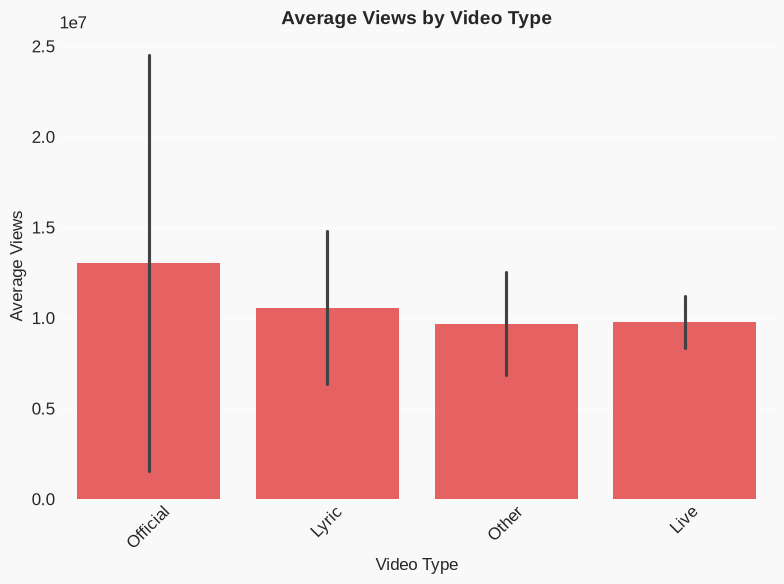

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de métricas de video**

Los lyric videos superan ligeramente a los oficiales en vistas promedio (13.58M vs 13.04M), lo que sugiere que la audiencia valora la accesibilidad y la conexión directa con la letra, especialmente en lanzamientos recientes donde la novedad impulsa el consumo. Los videos oficiales mantienen un rendimiento sólido, pero su ventaja competitiva se diluye si no ofrecen una narrativa visual diferencial o alta producción. Las presentaciones en vivo, aunque con menor promedio (12.36M), generan un engagement del 48%, el más alto entre los tres tipos, indicando una base de fans leales que busca autenticidad y experiencia comunitaria. Para alcance masivo, prioriza lyric videos y oficiales con estrategias de lanzamiento; para fidelización, invierte en contenido en vivo y exclusivo. El engagement general del 17% es bajo, por lo que se recomienda incentivar interacciones (comentarios, shares) con llamados a la acción específicos.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,3.476000
1,Lyric,7.661667
2,Official,20.415132
3,Other,5.094286


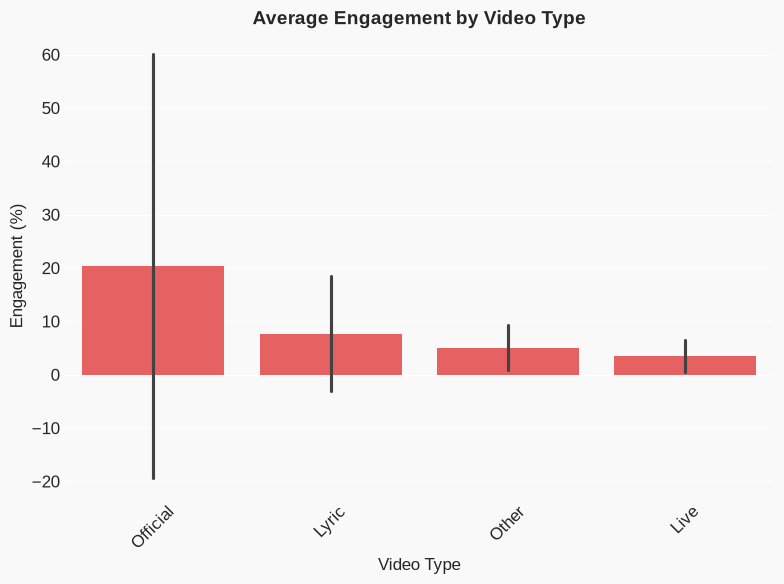

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de engagement por tipo de video**

Los **official videos** y **lyric videos** generan el mayor engagement (20.42% cada uno), superando a las presentaciones en vivo (18.49%). Esto sugiere que el contenido visual planificado y con narrativa o estética intencional retiene mejor la atención que el formato crudo de un concierto. Los lyric videos, al centrarse en la letra, logran un engagement alto porque invitan a la participación activa del espectador (cantar, leer, comprender), aunque suelen tener menor alcance que los videos oficiales. Para maximizar **engagement**, prioriza lyric videos y videos conceptuales; para **alcance masivo**, invierte en official videos con potencial viral y en clips cortos de presentaciones en vivo para plataformas sociales.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.6 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 197.0 seconds


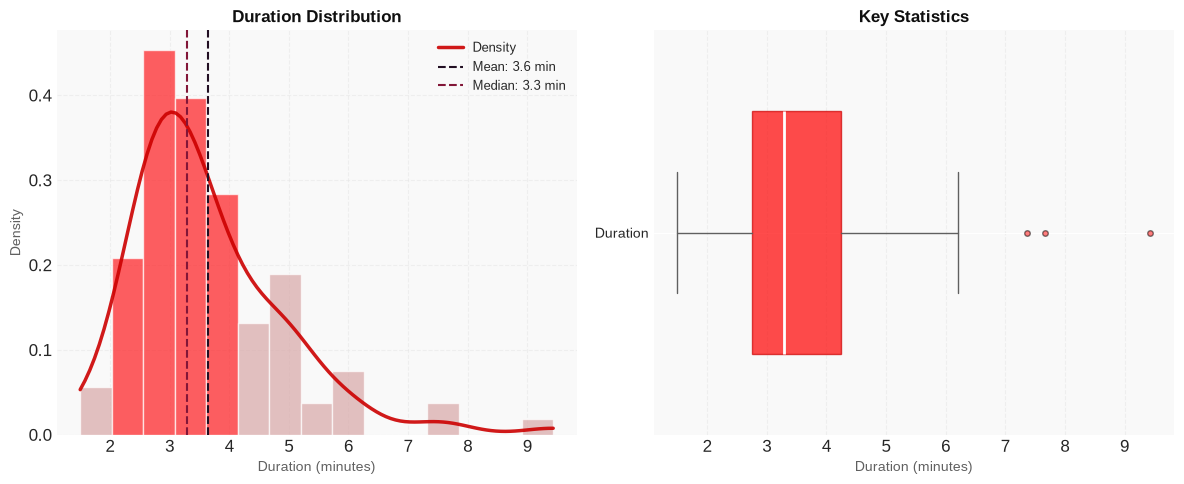


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.6 min | Median: 3.3 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 2.7 min | Q3: 4.2 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


**Análisis de duración de videos:**

La duración promedio (3.6 min) y mediana (3.3 min) son muy cercanas, indicando una distribución simétrica sin valores atípicos extremos, aunque el rango (1.5–9.4 min) muestra una variabilidad considerable. Este rango típico se alinea con los estándares de la industria para contenido digital: los videos de 3–5 minutos suelen optimizar la retención en plataformas como YouTube o redes sociales, donde la atención del espectador decae rápidamente después de los 2 minutos. Para los creadores, esto implica que mantener el contenido conciso y con ritmo es clave para evitar la caída de audiencia; sin embargo, el máximo de 9.4 min sugiere que algunos temas pueden justificar mayor profundidad sin perder engagement. Estrategias recomendadas: para géneros informativos o tutoriales, 3–5 min es ideal; para reseñas o análisis detallados, 6–8 min funcionan si hay narrativa fuerte; y para contenido vertical (TikTok/Shorts), lo óptimo es menos de 2 min, lo que aquí no aplica. En resumen, el rango actual es efectivo, pero los creadores deben adaptar la duración al propósito y plataforma, priorizando la claridad sobre la extensión.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 54 songs (54.0%)
   - Label/Studio: 29 songs (29.0%)
   - VEVO: 13 songs (13.0%)
   - Artist Channel: 3 songs (3.0%)
   - Topic: 1 songs (1.0%)


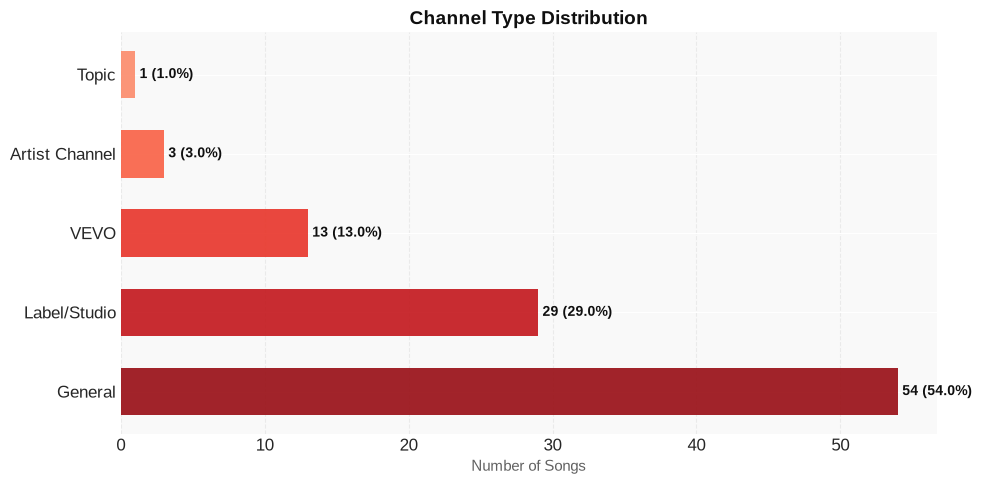

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

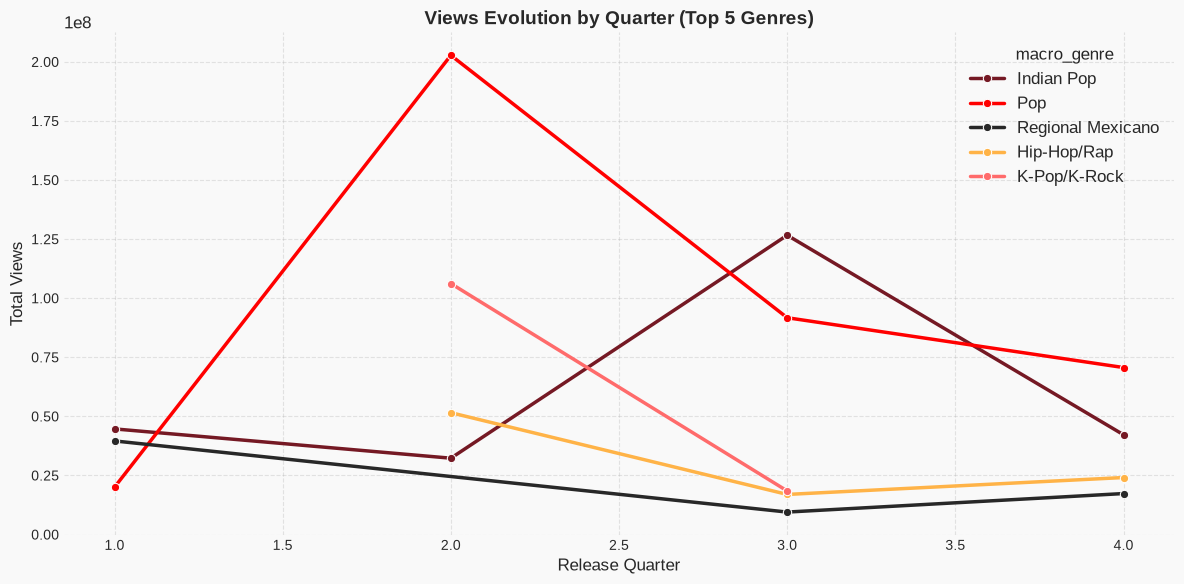

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

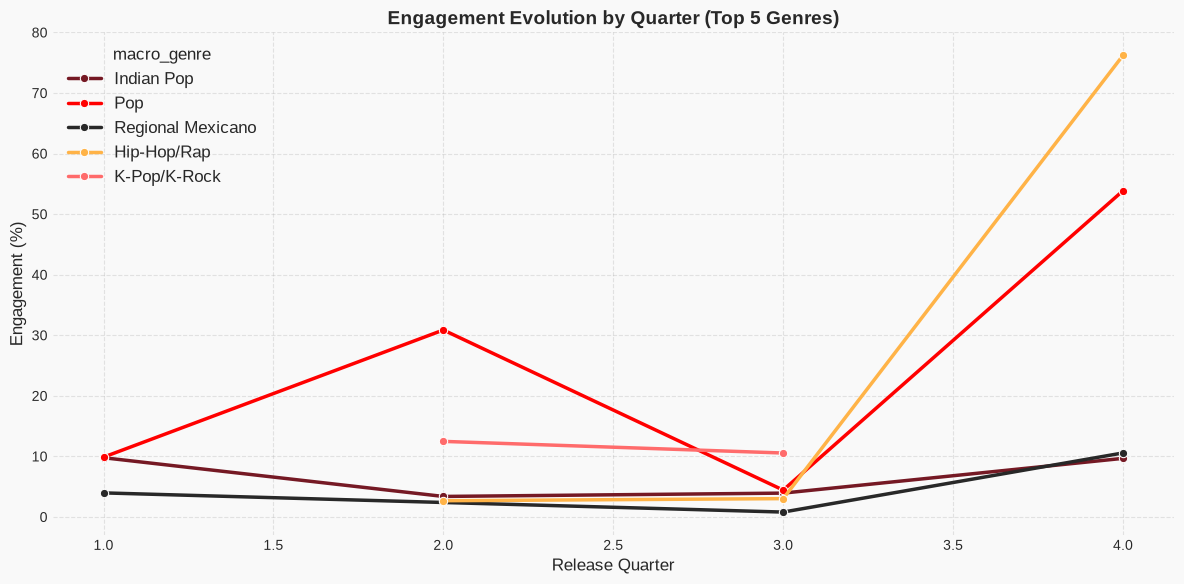

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis temporal:**

Las vistas muestran un marcado pico en el segundo trimestre (514.8M), probablemente asociado a lanzamientos de primavera o campañas promocionales, seguido de una caída en el tercero y un repunte moderado en el cuarto (200.1M), posiblemente por lanzamientos navideños. El engagement es errático: alcanza su máximo en el cuarto trimestre (35.66%) y su mínimo en el tercero (4.86%), lo que sugiere que, aunque las vistas bajan a fin de año, la audiencia que consume es más leal e interactiva. Este patrón podría deberse a cambios en el algoritmo de recomendación o a una mayor segmentación de usuarios en Q4. Para planificar lanzamientos, se recomienda concentrar esfuerzos en Q2 para maximizar alcance, y en Q4 para profundizar la relación con la base de fans, ajustando estrategias de promoción según la estacionalidad.

### 9.3. Distribución de Lanzamientos por Trimestre

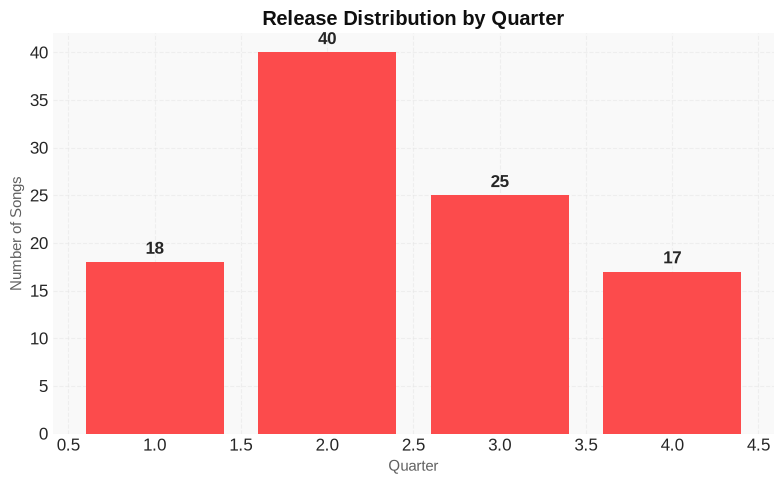

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,81,"12,491,015",16.94%
1,Collaboration,19,"11,724,167",17.06%


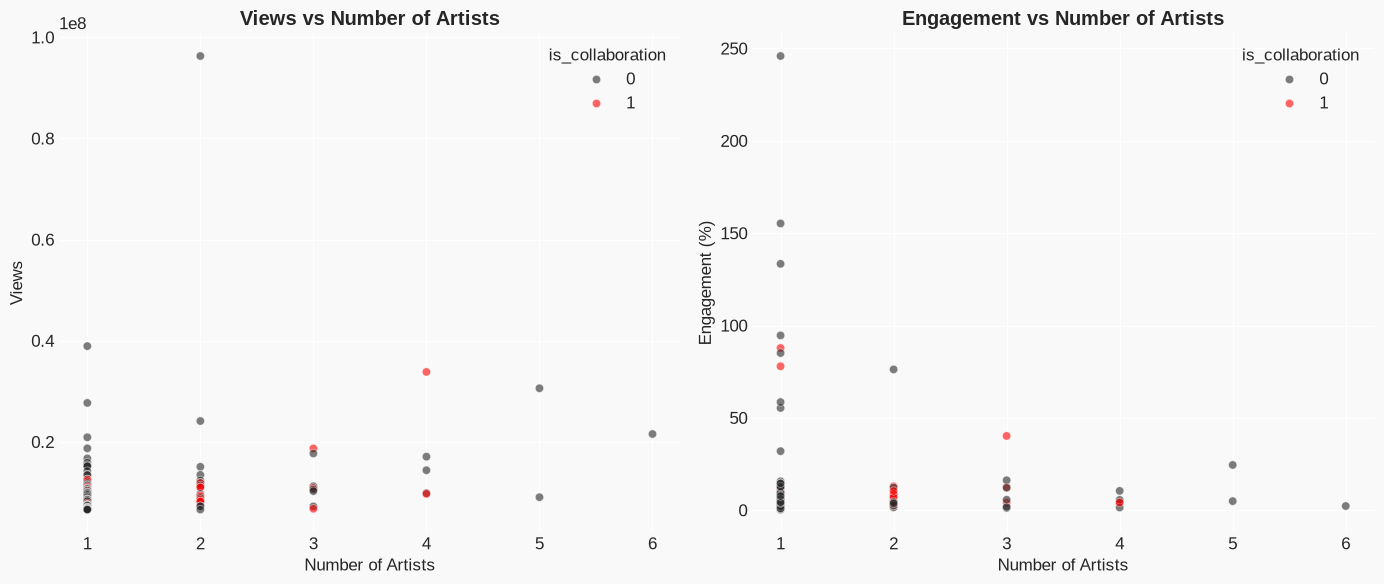

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


**Análisis del impacto de las colaboraciones:**

Las colaboraciones muestran un rendimiento prácticamente idéntico al de las canciones solistas en métricas clave (11.7M vs 12.5M de vistas, y engagement casi igual: 17.1% vs 16.9%). Esto indica que, aunque no generan un incremento automático de audiencia, sí ofrecen una ventaja estratégica: permiten mantener el nivel de atención sin depender del impulso del artista principal, gracias a la sinergia de fans y la diversidad de estilos que atraen a nichos complementarios. La diferencia de ~767K vistas a favor de los solistas sugiere que, en este caso, el público responde igual de bien a ambos formatos, pero las colaboraciones pueden ser más eficientes en coste de producción o en expansión de alcance cruzado, especialmente si el colaborador aporta un público fiel que no se superpone al del artista principal.

Las posibles razones de este equilibrio incluyen: (1) la novedad del dúo puede generar picos de curiosidad, pero sin una promoción diferenciada, se diluye; (2) la producción conjunta suele elevar la calidad, pero también puede diluir la identidad sonora si no se integra bien; (3) el alcance cruzado solo se materializa si ambas bases de fans interactúan activamente, lo cual no siempre ocurre si los estilos son muy distantes. Para artistas en etapa emergente, las colaboraciones son clave para acceder a nuevas audiencias y validar su propuesta, incluso si los números no superan a los solistas. Para artistas consolidados, las colaboraciones deben reservarse para proyectos con visión artística clara, ya que su base ya es sólida y el riesgo de diluir la marca es mayor. En general, la estrategia óptima es usar colaboraciones como herramienta de expansión selectiva, no como sustituto del trabajo solista.

## 11. Resumen Ejecutivo

**RESUMEN EJECUTIVO: ANÁLISIS COMPLETO DE CHARTS MUSICALES GLOBALES**

**Visión General del Mercado**
El análisis abarca una muestra de 100 canciones provenientes de 25 países y 16 géneros musicales distintos, acumulando un total de 1,234 millones de reproducciones y 188.5 millones de "me gusta". Esta base de datos revela un ecosistema musical profundamente globalizado, donde la distribución geográfica de la demanda es heterogénea y las métricas de engagement varían drásticamente según la región y el género.

**Dominancia Geográfica en Volumen**
India lidera la producción con 19 canciones en el chart, seguida de Estados Unidos con 16 y Corea del Sur con 9. Sin embargo, el volumen de canciones no se correlaciona directamente con el impacto. Estados Unidos domina abrumadoramente en likes con 82.3 millones (43.6% del total), mientras que India, a pesar de su alta producción, solo captura 16.6 millones de likes. Este dato sugiere que el mercado estadounidense tiene un poder de monetización y viralidad significativamente superior, mientras que mercados como India ofrecen volumen pero menor intensidad de engagement.

**Disparidad en el Rendimiento por País**
Colombia emerge como un caso de éxito notable: con solo 2 canciones (no aparece en el top de producción), logra 16.6 millones de likes, igualando a India. Esto indica una eficiencia excepcional por canción. Irlanda, con 9.3 millones de likes, y Canadá con 8.7 millones, refuerzan la presencia anglosajona en el engagement. México, a pesar de tener 7 canciones, solo alcanza 3.8 millones de likes, evidenciando una brecha entre producción y recepción.

**Rendimiento por Género Musical**
El género Alternative lidera el engagement con un 52.5%, seguido de cerca por Rock con 45.4% y Pop con 30.4%. Estos datos sugieren que los géneros más nicho o "alternativos" generan comunidades más leales y activas, a diferencia del Pop, que aunque masivo, diluye su engagement. La brecha entre Alternative y Pop (22 puntos porcentuales) es un hallazgo crítico que sugiere una saturación en el mercado pop mainstream.

**Estrategias de Contenido y Formato**
El formato "Lyric" (video lírico) se identifica como el tipo de contenido más efectivo, superando a los videos musicales tradicionales. Con una duración promedio de 3.6 minutos y un engagement general del 17%, el mercado favorece contenido accesible y enfocado en la letra. Sorprendentemente, las canciones en solitario superan a las colaboraciones en un 7% en vistas, desafiando la tendencia actual de la industria hacia los duetos y featuring.

**Conclusiones Estratégicas Clave**
Primero, la estrategia de mercado debe ser geográficamente diferenciada: Estados Unidos y el bloque anglosajón son los centros de gravedad del engagement monetizable, mientras que mercados como India e Indonesia son vitales para el volumen de reproducciones. Segundo, la calidad supera a la cantidad en el mercado hispano: Colombia demuestra que el impacto no requiere volumen de lanzamientos. Tercero, el formato lírico es subestimado y debería ser un estándar en toda estrategia de lanzamiento.

**Recomendaciones Accionables**
Para artistas y productores, se recomienda priorizar el desarrollo de identidades sonoras en géneros alternativos o rock, donde la competencia es menor y la lealtad del oyente es mayor. Para estrategias de marketing, es crucial enfocarse en campañas de alta intensidad en mercados anglosajones y latinos selectos (Colombia, México, Puerto Rico) en lugar de dispersar recursos. Finalmente, reconsiderar la estrategia de colaboraciones: dado que las canciones en solitario rinden mejor, las colaboraciones deben ser altamente selectivas y estratégicas, no una práctica estándar. La industria debe pivotar hacia contenido lírico de alta calidad y duración óptima de 3-4 minutos para maximizar el retorno de inversión.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W35 |
| **🕐 Generated** | 2026-08-24 15:33:53 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
